Test

In [573]:
import numpy as np
import scipy.stats as scp
import numpy.random as rnd
import matplotlib.pyplot as plt
import librosa as lb

# 1

## a

In [574]:
%matplotlib inline

In [575]:
states = np.arange(0,11,1)

In [576]:
statetransitions = np.zeros((len(states),len(states)))
statetransitions[0][0] = 0.9
statetransitions[0][1] = 0.1
statetransitions[10][-1] = 0.9
statetransitions[10][-2] = 0.1

for i in range(len(states)-2):
        
    statetransitions[i+1][0] = 0.1
    statetransitions[i+1][1] = 0.8
    statetransitions[i+1][2] = 0.1
    statetransitions[i+1] = np.roll(statetransitions[i+1],i)
    

In [577]:
statetransitions

array([[0.9, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9]])

## B

In [578]:
cumstatetransitions = np.cumsum(statetransitions,axis=1)

In [579]:
cumstatetransitions

array([[0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 1. ]])

In [580]:
numexperiments = 10
numtimesteps = 50
posarr = np.zeros([numexperiments,numtimesteps])
posarr[:,0] = 5

for experiment in range(numexperiments):
    rand = rnd.uniform(low=0,high=1,size=numtimesteps)
    for currenttime in range(1,numtimesteps):
        for state in range(len(statetransitions)):
            lastposition = int(posarr[experiment,currenttime-1])
            if rand[currenttime] < cumstatetransitions[lastposition][state]:
                posarr[experiment,currenttime] = state
                break
posarr = np.transpose(posarr)


Text(0.5, 0.98, '10 Random walks')

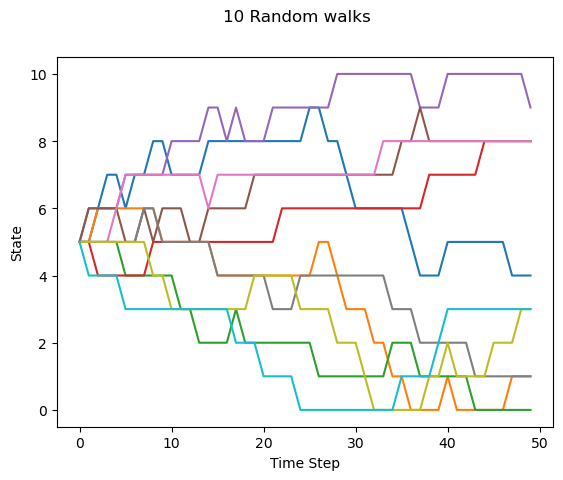

In [581]:
fig, ax = plt.subplots()
ax.plot(posarr)
ax.set_xlabel("Time Step")
ax.set_ylabel("State")
# ax.set_xlim(0,3)
fig.suptitle("10 Random walks")

## C

We can find the PMF empirecally or with a heck ton of simulations (monte carlo? Is that what this is? I've done it in phys64 and this feels similar, trying to guess a thing and approach it?)

## Math PMF

In [582]:
def matrixpower(mat,pow):
    if(pow == 0):
        return mat
    else:
        return mat@matrixpower(mat,pow-1)

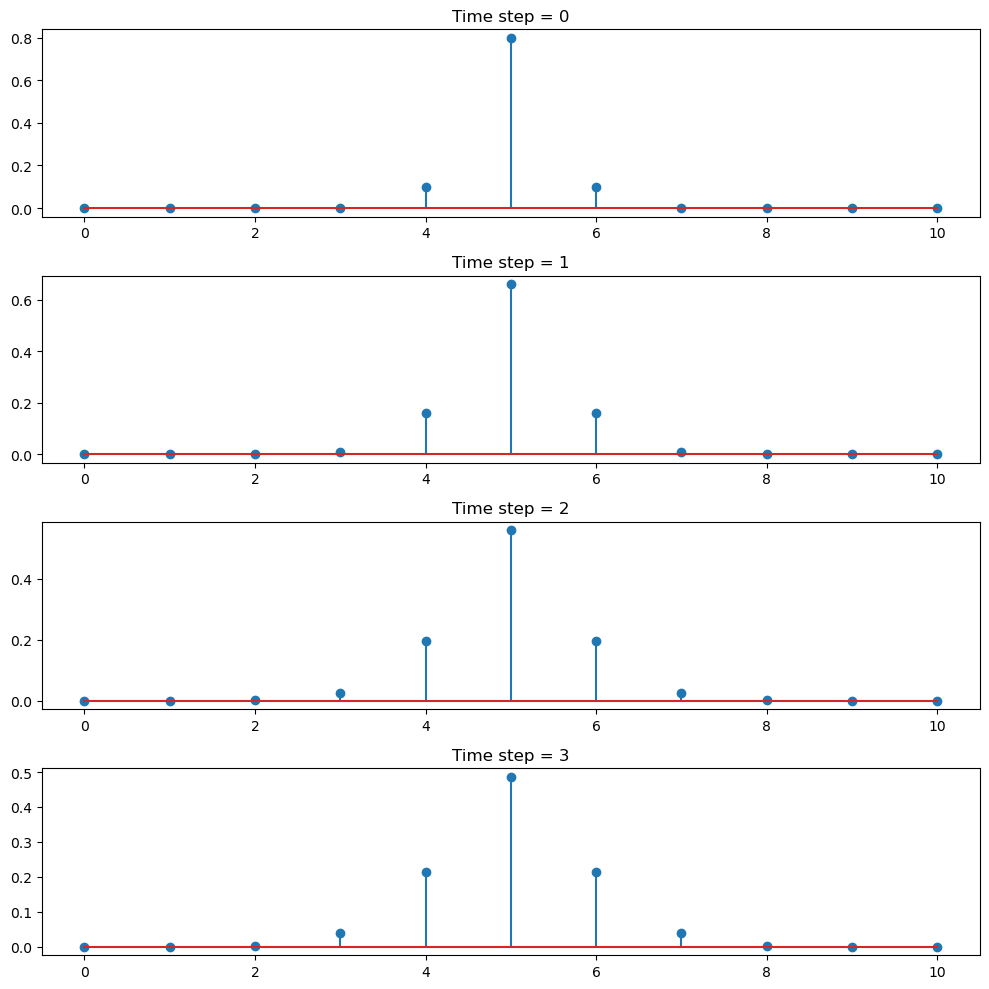

In [583]:
numsteps = 4
fig, ax = plt.subplots(numsteps,figsize=(10,10))
for i in range(numsteps):
    # pow = np.power(statetransitions,i)
    pow = matrixpower(statetransitions,i)
    currentpositionpmf = pow[5,:]
    # print(f"SUM: {np.sum(currentpositionpmf)}")
    # print(i)
    ax[i].stem(currentpositionpmf)
    ax[i].set_title("Time step = " + str(i))
    # ax[i].set_ylim(0,1)

    fig.tight_layout()


out of curiosity, I compare this with the simulated PMF but gave up because density doesn't work with weird binsizes?

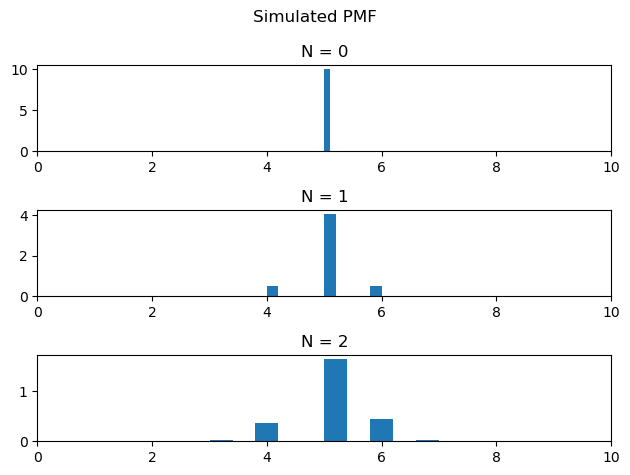

In [584]:
numexperiments = 1000
numtimesteps = 50
posarr = np.zeros([numexperiments,numtimesteps])
posarr[:,0] = 5

for experiment in range(numexperiments):
    rand = rnd.uniform(low=0,high=1,size=numtimesteps)
    for currenttime in range(1,numtimesteps):
        for state in range(len(statetransitions)):
            lastposition = int(posarr[experiment,currenttime-1])
            if rand[currenttime] < cumstatetransitions[lastposition][state]:
                posarr[experiment,currenttime] = state
                break
posarr = np.transpose(posarr)

numplottimesteps = 3
fig, ax = plt.subplots(numplottimesteps,1)
for i in range(numplottimesteps):
    # print(f"Data = {posarr[i,:]}")
    counts,bins = np.histogram(posarr[i,:])
    ax[i].hist(posarr[i,:],density=True)#,density=True,align="mid")
    ax[i].set_xlim(0,10)
    ax[i].set_title("N = " + str(i))
fig.suptitle("Simulated PMF")
fig.tight_layout()
# ax.plot(posarr)
# ax.set_xlabel("Time Step")
# ax.set_ylabel("State")
# fig.suptitle("10 Random walks")



## d

To find where the PMF was constant, we define a threshold 0.001 where the every value of the pmf for that number of steps and that number of steps + a huge number are within that threshold of each other. This means that the are in steady state - the pmf doesn't change even over massive timespans.

161


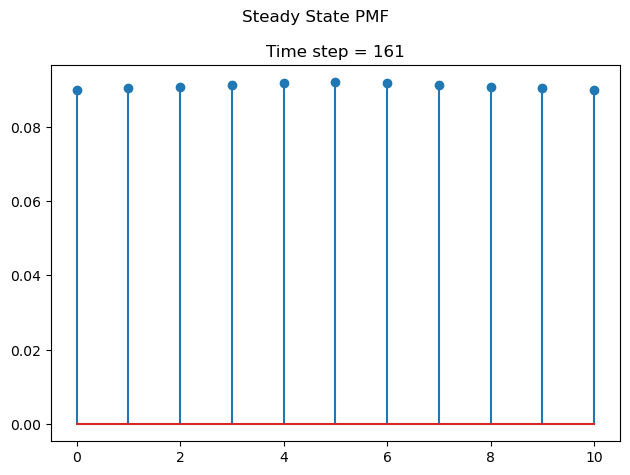

In [585]:
gooddiff = False

stepsaway = 1000
threshold = 0.001
minval = 1
while(not gooddiff):
    
    pow1 = matrixpower(statetransitions,minval)
    pow2 = matrixpower(statetransitions,minval+stepsaway)
    diff = np.abs(pow1[5,:]-pow2[5,:])
    # print(diff)
    if(np.all(diff<= threshold)):
        gooddiff = True
        print(minval)
    else:
        minval = minval + 1

fig, ax = plt.subplots()

ax.stem(pow1[5,:])

ax.set_title("Time step = " + str(minval))
fig.suptitle("Steady State PMF")

# ax.set_ylim(0,1)

fig.tight_layout()


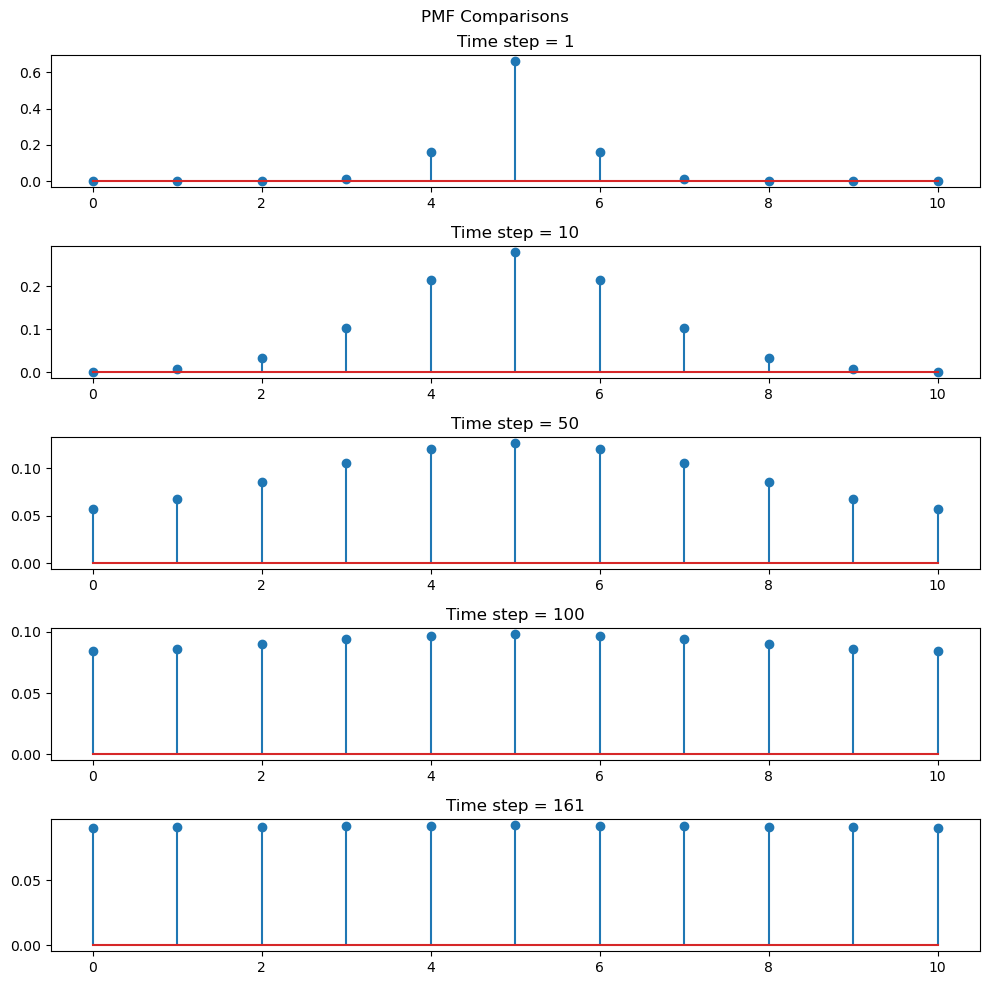

In [586]:
gooddiff = False

stepsaway = 1000
threshold = 0.001
minval = 1

timestepsarr = [1,10,50,100,161]

fig, ax = plt.subplots(len(timestepsarr),figsize=(10,10))
for i in range(len(timestepsarr)):

    pow = matrixpower(statetransitions,timestepsarr[i])
    ax[i].stem(pow[5,:])

    ax[i].set_title("Time step = " + str(timestepsarr[i]))
fig.suptitle("PMF Comparisons")

# ax.set_ylim(0,1)

fig.tight_layout()


## E

In [587]:
numexperiments = 10
numtimesteps = 50
posarr = np.zeros([numexperiments,numtimesteps])
posarr[:,0] = 5

for experiment in range(numexperiments):
    rand = rnd.uniform(low=0,high=1,size=numtimesteps)
    for currenttime in range(1,numtimesteps):
        for state in range(len(statetransitions)):
            lastposition = int(posarr[experiment,currenttime-1])
            if rand[currenttime] < cumstatetransitions[lastposition][state]:
                posarr[experiment,currenttime] = state
                break
posarr = np.transpose(posarr)


In [588]:

path = posarr[:,7]
# plt.plot(path)

In [589]:
variances = [0.1,0.5,1]
variancenames = ["low","med","high"]
noises = np.zeros((3,len(path)))
for i in range(len(variances)):
    noises[i,:] = rnd.normal(0,variances[i],len(path))

In [590]:
# np.shape(noises[1,:])

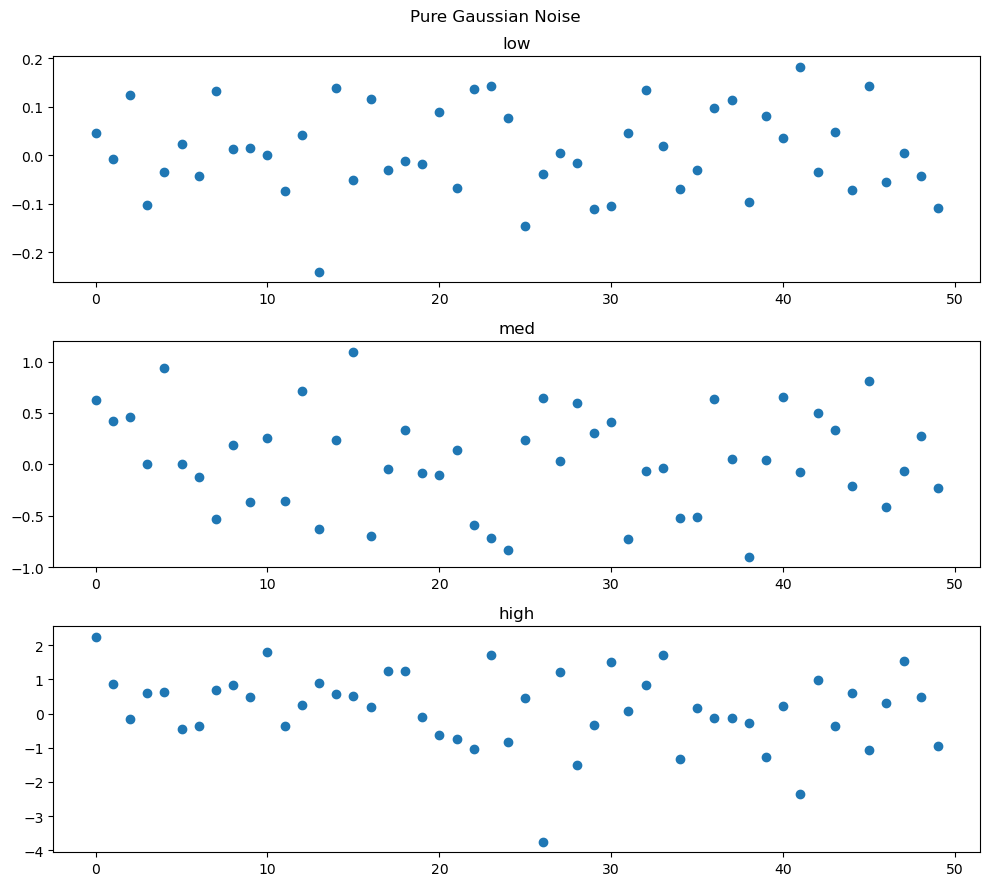

In [591]:
fig, ax = plt.subplots(numplottimesteps,1,figsize=(10,9))
for i in range(len(variances)):
    ax[i].scatter(np.arange(len(noises[i,:])),noises[i,:])
    ax[i].set_title(variancenames[i])
fig.suptitle("Pure Gaussian Noise")
fig.tight_layout()


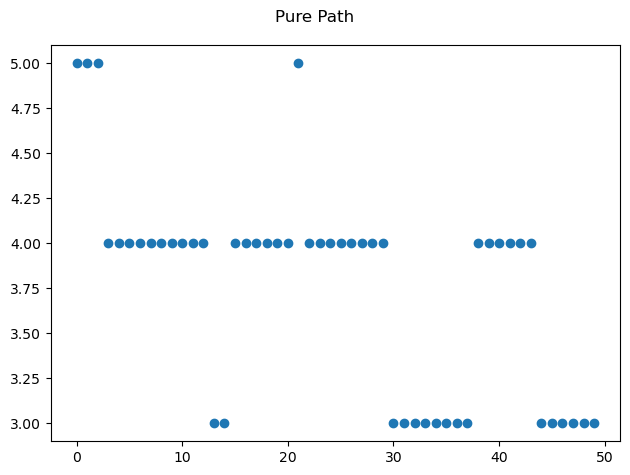

In [592]:
fig, ax = plt.subplots(1)
ax.scatter(np.arange(len(path)),path)    
fig.suptitle("Pure Path")
fig.tight_layout()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Sorin\AppData\Local\Temp\ipykernel_39268\4239940391.py:4: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(variancenames[i] + " $\sigma^2=$" + str(variances[i]))


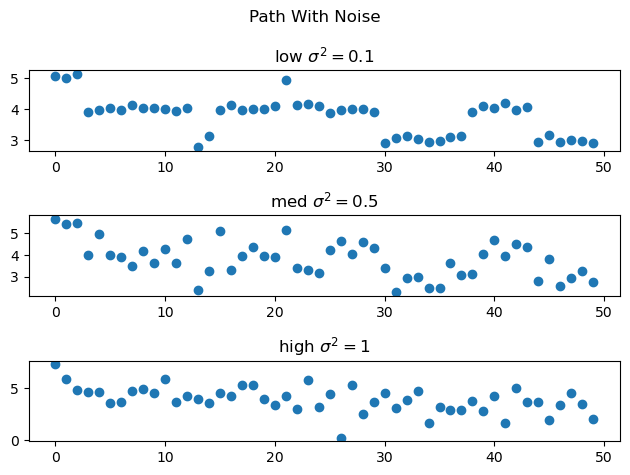

In [593]:
fig, ax = plt.subplots(numplottimesteps,1)#,figsize=(10,9))
for i in range(len(variances)):
    ax[i].scatter(np.arange(len(path)),path+noises[i,:])
    ax[i].set_title(variancenames[i] + " $\sigma^2=$" + str(variances[i]))
    # ax[i].set_ylim(0,12)
fig.suptitle("Path With Noise")
fig.tight_layout()

## F

In [594]:
def constructSimilarityMatrix(pathObserved):
    numtimes = 50
    numstates = 11

    probabilityMatrix = np.zeros((numstates,numtimes))

    for i in range(numtimes):
        pow = matrixpower(statetransitions,i)
        observation = pathObserved[i]
        for j in range(numstates):
            pdf =  pow[j,:]

            lower = int(np.floor(observation))
            upper = int(np.ceil(observation))
            if(upper > numstates):
                upper = 9999
            if(lower > 10):
                lower = 0
            if(np.abs(observation-lower) < np.abs(upper-observation) or upper >= numstates-1):
                # print(f"lower: {lower}")
                probabilityMatrix[j,i] = probabilityMatrix[j,i] + pdf[lower]
            else:
                # print(f"upper: {upper}")
                probabilityMatrix[j,i] = probabilityMatrix[j,i] + pdf[upper]

    return probabilityMatrix

In [595]:
variances

[0.1, 0.5, 1]

In [596]:
pathset = np.array([path,path+noises[0,:],path+noises[1,:],path+noises[2,:]])
pathnames = ["pure", "low noise", "medium noise", "high noise"]

In [597]:
np.shape(pathset)

(4, 50)

In [598]:
similarities = []
for i in range(np.shape(pathset)[0]):
    similarities.append(constructSimilarityMatrix(pathset[i,:]))

In [599]:
np.shape(similarities[1][1,:])

(50,)

In [600]:
states = np.zeros((4,50))
for i in range(4):
    states[i,:] = lb.sequence.viterbi(prob=similarities[i],transition=statetransitions)
# statesnoisemed = lb.sequence.viterbi(prob=noisepathSimilarityMed,transition=statetransitions)
# statesnoiselarge = lb.sequence.viterbi(prob=noisepathSimilarityLarge,transition=statetransitions)

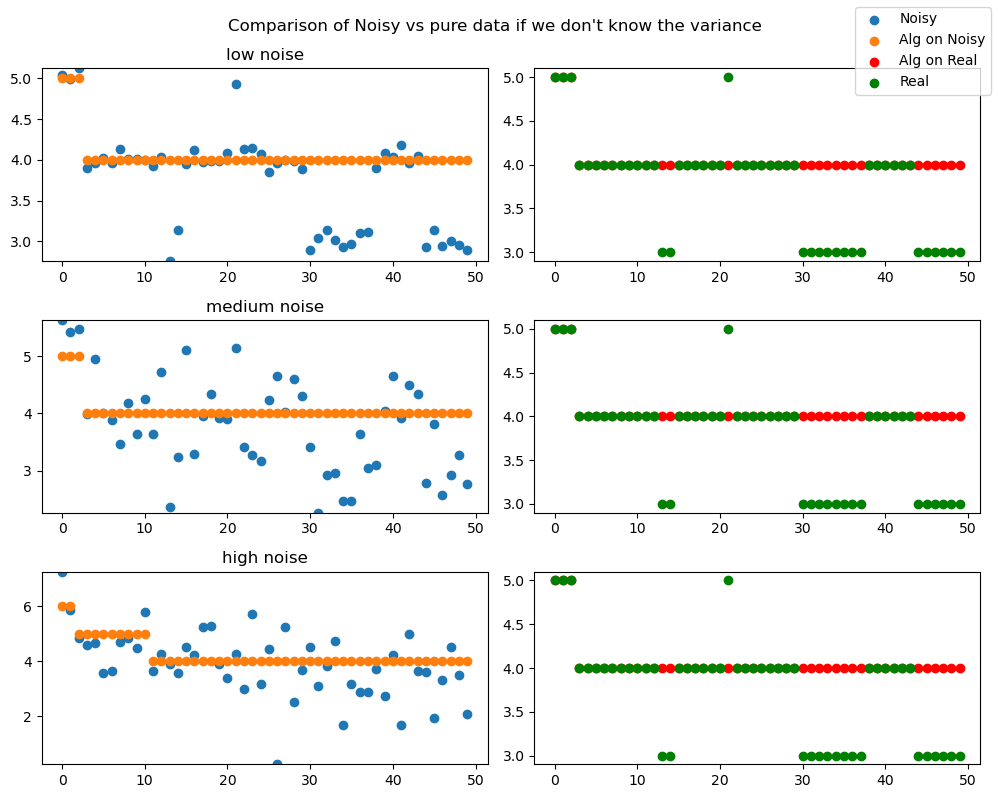

In [626]:
fig, ax = plt.subplots(3,2,figsize=(10,8))
for i in range(1,4):
    
    ax[i-1][0].scatter(np.arange(len(states[i,:])),pathset[i,:]) # noisy data
    ax[i-1][0].scatter(np.arange(len(states[i,:])),states[i,:]) # algorithm on noisy data
    ax[i-1][1].scatter(np.arange(len(states[0,:])),states[0,:],color="red") # algorithm on real data
    ax[i-1][1].scatter(np.arange(len(states[0,:])),path,color="green") # real data
    
    ax[i-1][0].set_title(pathnames[i])
    ax[i-1][0].set_ylim((min(min(path),min(pathset[i,:])),max(max(path),max(pathset[i,:]))))
fig.legend(["Noisy","Alg on Noisy","Alg on Real","Real"])
fig.suptitle("Comparison of Noisy vs pure data if we don't know the variance")
fig.tight_layout()